<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/fundamentals_of_probability_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


In [36]:
import numpy as np
import matplotlib.pyplot as plt

R = 10  # radius of disk

# ── Part 1: Uniform w.r.t. Area ──────────────────────────────────────────────
# A = {point lies within 1 unit of boundary} = annulus [9, 10]
# Area of disk = π R²   Area of inner disk (r ≤ 9) = π·9²
P_A_area = (np.pi * R**2 - np.pi * 9**2) / (np.pi * R**2)
print(f"Part 1 – Uniform w.r.t. Area:")
print(f"  P(A) = (π·10² - π·9²) / π·10²  =  (100 - 81)/100  =  19/100  = {P_A_area:.4f}")

# ── Part 2: Uniform distance from center ─────────────────────────────────────
# r ~ Uniform[0, 10], independent θ ~ Uniform[0, 2π)
# A = {r ≥ 9}
# P(A) = P(r ∈ [9,10]) = (10 - 9)/(10 - 0)
P_A_dist = (10 - 9) / (10 - 0)
print(f"\nPart 2 – Uniform Distance:")
print(f"  P(A) = (10 - 9) / 10  =  1/10  = {P_A_dist:.4f}")

# ── Part 3: Explanation ───────────────────────────────────────────────────────
print("""
Part 3 – Why the answers differ:
  The two models assign probability in fundamentally different ways.

  Model 1 (uniform in area): equal probability to equal *areas*.
    Points near the boundary cover a large area (the wide annulus), so
    the boundary region gets high probability ≈ 19%.

  Model 2 (uniform in radial distance): equal probability to equal
    *radial intervals*.  The interval [9,10] is only 1/10 of [0,10],
    so P(A) = 10%, regardless of how much area that annulus covers.

  "Uniform" is not absolute—it depends on the measure (area vs. length
  of radius).  The two models induce different probability measures on
  the same sample space, so they give different numbers.
""")

# ── Verification by Monte-Carlo ───────────────────────────────────────────────
np.random.seed(42)
N = 1_000_000

# Model 1: rejection sampling inside disk
pts = []
while len(pts) < N:
    x, y = np.random.uniform(-R, R, 2)
    if x**2 + y**2 <= R**2:
        pts.append((x, y))
pts = np.array(pts)
r_area = np.sqrt(pts[:,0]**2 + pts[:,1]**2)
mc1 = np.mean(r_area >= 9)

# Model 2: r uniform, θ uniform
r_dist = np.random.uniform(0, R, N)
mc2 = np.mean(r_dist >= 9)

print(f"Monte-Carlo verification (N={N:,}):")
print(f"  Model 1 P(A) ≈ {mc1:.4f}  (exact {P_A_area:.4f})")
print(f"  Model 2 P(A) ≈ {mc2:.4f}  (exact {P_A_dist:.4f})")


Part 1 – Uniform w.r.t. Area:
  P(A) = (π·10² - π·9²) / π·10²  =  (100 - 81)/100  =  19/100  = 0.1900

Part 2 – Uniform Distance:
  P(A) = (10 - 9) / 10  =  1/10  = 0.1000

Part 3 – Why the answers differ:
  The two models assign probability in fundamentally different ways.

  Model 1 (uniform in area): equal probability to equal *areas*.
    Points near the boundary cover a large area (the wide annulus), so
    the boundary region gets high probability ≈ 19%.

  Model 2 (uniform in radial distance): equal probability to equal
    *radial intervals*.  The interval [9,10] is only 1/10 of [0,10],
    so P(A) = 10%, regardless of how much area that annulus covers.

  "Uniform" is not absolute—it depends on the measure (area vs. length
  of radius).  The two models induce different probability measures on
  the same sample space, so they give different numbers.

Monte-Carlo verification (N=1,000,000):
  Model 1 P(A) ≈ 0.1898  (exact 0.1900)
  Model 2 P(A) ≈ 0.1001  (exact 0.1000)


# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

Method 1 (random endpoints):  P = 2/3 ≈ 0.6667
  Monte-Carlo ≈ 0.3329

Method 2 (random midpoint):  P = 1/4 = 0.2500
  Monte-Carlo ≈ 0.2495

Method 3 (random radius):  P = 1/2 = 0.5000
  Monte-Carlo ≈ 0.5001

Explanation of Bertrand's Paradox:
  The three methods each define a mathematically natural probability
  measure on the space of chords, but they are *different* measures.
  The phrase "chosen at random" is ambiguous unless the underlying
  probability space is specified.  This illustrates that probability
  is not determined by geometry alone—the choice of sample space and
  measure matters.



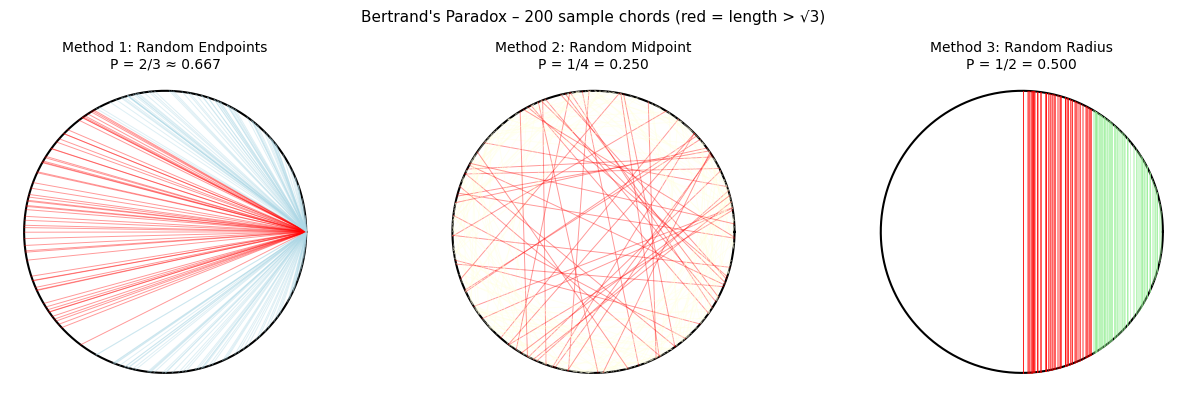

Plot saved as bertrand_paradox.png


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ── Background ───────────────────────────────────────────────────────────────
# Circle of radius 1.  Inscribed equilateral triangle side = √3.
# A chord is longer than √3  ⟺  its length > √3.
# Three classical "uniform" models give three different answers.

R = 1.0
side_len = np.sqrt(3)          # side of inscribed equilateral triangle

# ═══════════════════════════════════════════════════════════════════════════
# METHOD 1 – Random Endpoints  (uniform endpoint pair on the circle)
#   Fix one endpoint at angle 0.  Second endpoint θ ~ Uniform[0, 2π).
#   Chord length = 2 sin(θ/2).  Chord > √3  ⟺  sin(θ/2) > √3/2  ⟺  θ ∈ (π/3, 5π/3).
#   P = (5π/3 - π/3) / 2π  =  4π/3 / 2π  =  2/3
P1_exact = 2/3
print(f"Method 1 (random endpoints):  P = 2/3 ≈ {P1_exact:.4f}")

np.random.seed(0)
N = 2_000_000
theta = np.random.uniform(0, 2*np.pi, N)
lengths1 = 2 * np.sin(theta / 2)
mc1 = np.mean(lengths1 > side_len)
print(f"  Monte-Carlo ≈ {mc1:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# METHOD 2 – Random Midpoint  (midpoint uniform over the disk)
#   Chord longer than √3  ⟺  midpoint within radius 1/2 of center.
#   P = π(1/2)² / π(1)²  =  1/4
P2_exact = 1/4
print(f"\nMethod 2 (random midpoint):  P = 1/4 = {P2_exact:.4f}")

x = np.random.uniform(-1, 1, N * 5)
y = np.random.uniform(-1, 1, N * 5)
mask = x**2 + y**2 <= 1
x, y = x[mask][:N], y[mask][:N]
# chord length from midpoint distance d: chord = 2√(R² - d²)
d = np.sqrt(x**2 + y**2)
lengths2 = 2 * np.sqrt(np.maximum(R**2 - d**2, 0))
mc2 = np.mean(lengths2 > side_len)
print(f"  Monte-Carlo ≈ {mc2:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# METHOD 3 – Random Radius  (midpoint on a fixed radius, uniform in [0,1])
#   Chord longer than √3  ⟺  distance to center d < 1/2.
#   P = (1/2) / 1  =  1/2
P3_exact = 1/2
print(f"\nMethod 3 (random radius):  P = 1/2 = {P3_exact:.4f}")

d3 = np.random.uniform(0, R, N)
lengths3 = 2 * np.sqrt(np.maximum(R**2 - d3**2, 0))
mc3 = np.mean(lengths3 > side_len)
print(f"  Monte-Carlo ≈ {mc3:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
print("""
Explanation of Bertrand's Paradox:
  The three methods each define a mathematically natural probability
  measure on the space of chords, but they are *different* measures.
  The phrase "chosen at random" is ambiguous unless the underlying
  probability space is specified.  This illustrates that probability
  is not determined by geometry alone—the choice of sample space and
  measure matters.
""")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = [f'Method 1: Random Endpoints\nP = 2/3 ≈ {P1_exact:.3f}',
          f'Method 2: Random Midpoint\nP = 1/4 = {P2_exact:.3f}',
          f'Method 3: Random Radius\nP = 1/2 = {P3_exact:.3f}']
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, title, col in zip(axes, titles, colors):
    theta_circ = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta_circ), np.sin(theta_circ), 'k', lw=1.5)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.axis('off')

# Sample 200 chords for each method and colour-code
n_show = 200

# Method 1
theta2 = np.random.uniform(0, 2*np.pi, n_show)
x1a, y1a = np.cos(0), np.sin(0)
x1b, y1b = np.cos(theta2), np.sin(theta2)
lengths_show1 = 2 * np.sin(theta2 / 2)
for i in range(n_show):
    col = 'red' if lengths_show1[i] > side_len else 'lightblue'
    axes[0].plot([x1a, x1b[i]], [y1a, y1b[i]], color=col, alpha=0.4, lw=0.7)

# Method 2
xs = np.random.uniform(-1, 1, n_show * 10)
ys = np.random.uniform(-1, 1, n_show * 10)
mk = xs**2 + ys**2 <= 1
xs, ys = xs[mk][:n_show], ys[mk][:n_show]
ds = np.sqrt(xs**2 + ys**2)
for i in range(n_show):
    angle = np.arctan2(ys[i], xs[i])
    half = np.sqrt(max(1 - ds[i]**2, 0))
    perp = angle + np.pi/2
    x2a = xs[i] + half*np.cos(perp); y2a = ys[i] + half*np.sin(perp)
    x2b = xs[i] - half*np.cos(perp); y2b = ys[i] - half*np.sin(perp)
    chord_len = 2*half
    col = 'red' if chord_len > side_len else 'lightyellow'
    axes[1].plot([x2a, x2b], [y2a, y2b], color=col, alpha=0.4, lw=0.7)

# Method 3
ds3 = np.random.uniform(0, 1, n_show)
for i in range(n_show):
    half = np.sqrt(max(1 - ds3[i]**2, 0))
    col = 'red' if 2*half > side_len else 'lightgreen'
    axes[2].plot([ds3[i], ds3[i]], [-half, half], color=col, alpha=0.4, lw=0.7)

plt.suptitle("Bertrand's Paradox – 200 sample chords (red = length > √3)", fontsize=11)
plt.tight_layout()
plt.savefig('bertrand_paradox.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as bertrand_paradox.png")


#Q3) Transformer Failiures

In a certain electricity distribution district, the number of emergency transformer failures reported in a single day is modeled as a discrete random variable $X$. Assume that $X$ takes values in the set $\{0,1,2,3\}$, with probabilities

$$
P(X=0)=0.50,\qquad P(X=1)=0.30,\qquad P(X=2)=0.15,\qquad P(X=3)=0.05.
$$

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2. Define $X$ as a random variable on this space.
3. Determine the probability mass function of $X$.
4. Compute the expectation $E[X]$.
5. Compute the variance $\mathrm{Var}(X)$.
6. Find $P(X\ge 1)$ and $P(X\ge 2)$.
7. Briefly explain the practical meaning of the expectation and variance in this setting.



1. Probability Space (Ω, F, P):
   Ω = {0, 1, 2, 3}  (number of failures in a day)
   F = P(Ω) = all subsets of Ω  (power set, 16 elements)
   P is the probability measure defined by the PMF below.

2 & 3. X is the identity map X(ω) = ω; PMF of X:
   P(X = 0) = 0.5
   P(X = 1) = 0.3
   P(X = 2) = 0.15
   P(X = 3) = 0.05
   Sum of probabilities = 1.00  ✓

4. E[X] = Σ x·P(X=x) = 0·0.5 + 1·0.3 + 2·0.15 + 3·0.05
        = 0.7500

5. E[X²] = 1.3500
   Var(X) = E[X²] - (E[X])² = 1.3500 - 0.5625 = 0.7875
   Std(X) = 0.8874

6. P(X ≥ 1) = 1 - P(X=0) = 1 - 0.5 = 0.5
   P(X ≥ 2) = P(X=2) + P(X=3) = 0.15 + 0.05 = 0.2

7. Practical Interpretation:
   E[X] ≈ 0.75:  On average, we expect about 0.75 transformer failures per day,
                  meaning roughly 3 failures every 4 days.

   Var(X) ≈ 0.7375:  The variability around this average is moderate.
                      The standard deviation ≈ 0.86 failures/day suggests
                      that on many days there are 0 failures, but occasi

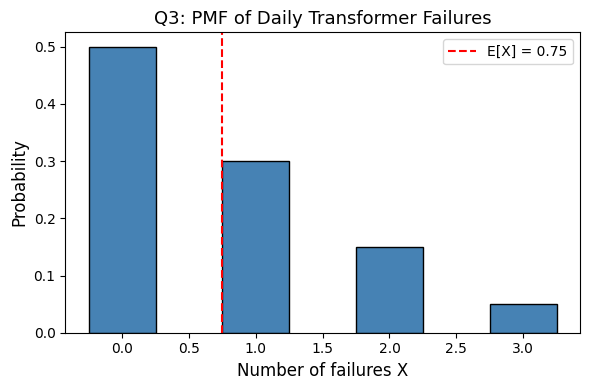

In [38]:
import numpy as np

# ── Q3: Transformer Failures ──────────────────────────────────────────────────

# 1. Probability space
print("1. Probability Space (Ω, F, P):")
print("   Ω = {0, 1, 2, 3}  (number of failures in a day)")
print("   F = P(Ω) = all subsets of Ω  (power set, 16 elements)")
print("   P is the probability measure defined by the PMF below.")

# 2 & 3. Random variable and PMF
values = np.array([0, 1, 2, 3])
probs  = np.array([0.50, 0.30, 0.15, 0.05])

print("\n2 & 3. X is the identity map X(ω) = ω; PMF of X:")
for v, p in zip(values, probs):
    print(f"   P(X = {v}) = {p}")
print(f"   Sum of probabilities = {probs.sum():.2f}  ✓")

# 4. Expectation E[X]
E_X = np.sum(values * probs)
print(f"\n4. E[X] = Σ x·P(X=x) = {' + '.join(f'{v}·{p}' for v,p in zip(values,probs))}")
print(f"        = {E_X:.4f}")

# 5. Variance Var(X)
E_X2 = np.sum(values**2 * probs)
Var_X = E_X2 - E_X**2
print(f"\n5. E[X²] = {E_X2:.4f}")
print(f"   Var(X) = E[X²] - (E[X])² = {E_X2:.4f} - {E_X**2:.4f} = {Var_X:.4f}")
print(f"   Std(X) = {np.sqrt(Var_X):.4f}")

# 6. P(X >= 1) and P(X >= 2)
P_ge1 = 1 - probs[0]
P_ge2 = probs[2] + probs[3]
print(f"\n6. P(X ≥ 1) = 1 - P(X=0) = 1 - {probs[0]} = {P_ge1}")
print(f"   P(X ≥ 2) = P(X=2) + P(X=3) = {probs[2]} + {probs[3]} = {P_ge2}")

# 7. Interpretation
print("""
7. Practical Interpretation:
   E[X] ≈ 0.75:  On average, we expect about 0.75 transformer failures per day,
                  meaning roughly 3 failures every 4 days.

   Var(X) ≈ 0.7375:  The variability around this average is moderate.
                      The standard deviation ≈ 0.86 failures/day suggests
                      that on many days there are 0 failures, but occasionally
                      there may be 2 or 3, so operational planning should
                      maintain repair capacity for at least 1–2 failures/day.
""")

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(values, probs, color='steelblue', edgecolor='black', width=0.5)
ax.axvline(E_X, color='red', linestyle='--', label=f'E[X] = {E_X:.2f}')
ax.set_xlabel('Number of failures X', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Q3: PMF of Daily Transformer Failures', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('q3_pmf.png', dpi=100, bbox_inches='tight')
plt.show()


# Q4) Probability of Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=
\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

2. Define $X$ as a continuous random variable on this space.

3. Write down the probability density function of $X$.

4. Verify that $f$ is a valid probability density function.

5. Compute the expectation $E[X]$.

6. Compute the variance $\mathrm{Var}(X)$.

7. Find the probability that the defective proportion is at most $0.10$, that is, compute

$$
P(X\le 0.10).
$$

You may leave your answer in Beta integral form.

8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute

$$
P(0.05\le X\le 0.15).
$$

You may leave your answer in integral form.

9. Briefly explain why a Beta distribution is a reasonable model for this situation.

10. Interpret the expectation and variance in the context of production quality.


1. Probability Space (Ω, F, P):
   Ω = [0,1]  (all possible defect proportions)
   F = Borel σ-algebra on [0,1]
   P is induced by the Beta(2,18) density

2. X: Ω → [0,1], X(ω) = ω  (identity; represents defect proportion)

3. PDF of X ~ Beta(2,18):
   f(x) = x^1 (1-x)^17 / B(2,18),   0 < x < 1
   B(2,18) = 2.923977e-03

4. ∫₀¹ f(x)dx = 1.000000  ✓  (must be 1.0)

5. E[X] = α/(α+β) = 2/(2+18) = 0.1000

6. Var(X) = αβ / [(α+β)²(α+β+1)]
          = 2·18 / (20)²·21
          = 0.004286
   Std(X) = 0.0655

7. P(X ≤ 0.10) = ∫₀^0.10 f(x)dx ≈ 0.5797
   (In Beta-integral form: I_{0.10}(2,18) where I is the regularised incomplete Beta)

8. P(0.05 ≤ X ≤ 0.15) = ∫_0.05^0.15 f(x)dx ≈ 0.5562

9. Why Beta(2,18) is reasonable:
   - X represents a proportion, so it naturally lives in [0,1].
   - The Beta family is the most flexible distribution on [0,1].
   - α=2, β=18 places most mass near 0 (low defect rates), consistent
     with a well-controlled manufacturing line.
   - E[X]=2/20=0.10 means 10% a

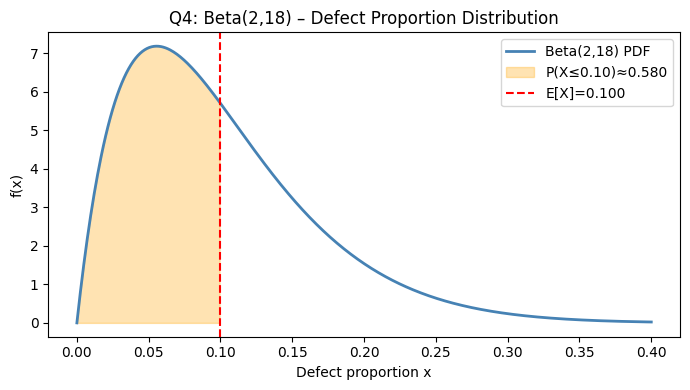

In [39]:
import numpy as np
from scipy.stats import beta as beta_dist
from scipy.special import beta as beta_fn
import matplotlib.pyplot as plt

alpha, b_param = 2, 18   # Beta(2,18)

# 1. Probability space
print("1. Probability Space (Ω, F, P):")
print("   Ω = [0,1]  (all possible defect proportions)")
print("   F = Borel σ-algebra on [0,1]")
print("   P is induced by the Beta(2,18) density")

# 2. X as a continuous RV
print("\n2. X: Ω → [0,1], X(ω) = ω  (identity; represents defect proportion)")

# 3. PDF
print("\n3. PDF of X ~ Beta(2,18):")
print("   f(x) = x^1 (1-x)^17 / B(2,18),   0 < x < 1")
print(f"   B(2,18) = {beta_fn(alpha, b_param):.6e}")

# 4. Verify ∫f = 1
from scipy.integrate import quad
integral, _ = quad(lambda x: beta_dist.pdf(x, alpha, b_param), 0, 1)
print(f"\n4. ∫₀¹ f(x)dx = {integral:.6f}  ✓  (must be 1.0)")

# 5. Expectation E[X] = α/(α+β)
E_X = alpha / (alpha + b_param)
print(f"\n5. E[X] = α/(α+β) = {alpha}/({alpha}+{b_param}) = {E_X:.4f}")

# 6. Variance Var(X) = αβ/[(α+β)²(α+β+1)]
Var_X = (alpha * b_param) / ((alpha + b_param)**2 * (alpha + b_param + 1))
print(f"\n6. Var(X) = αβ / [(α+β)²(α+β+1)]")
print(f"          = {alpha}·{b_param} / ({alpha+b_param})²·{alpha+b_param+1}")
print(f"          = {Var_X:.6f}")
print(f"   Std(X) = {np.sqrt(Var_X):.4f}")

# 7. P(X ≤ 0.10)
P_le_010 = beta_dist.cdf(0.10, alpha, b_param)
print(f"\n7. P(X ≤ 0.10) = ∫₀^0.10 f(x)dx ≈ {P_le_010:.4f}")
print("   (In Beta-integral form: I_{0.10}(2,18) where I is the regularised incomplete Beta)")

# 8. P(0.05 ≤ X ≤ 0.15)
P_band = beta_dist.cdf(0.15, alpha, b_param) - beta_dist.cdf(0.05, alpha, b_param)
print(f"\n8. P(0.05 ≤ X ≤ 0.15) = ∫_0.05^0.15 f(x)dx ≈ {P_band:.4f}")

# 9. Why Beta is reasonable
print("""
9. Why Beta(2,18) is reasonable:
   - X represents a proportion, so it naturally lives in [0,1].
   - The Beta family is the most flexible distribution on [0,1].
   - α=2, β=18 places most mass near 0 (low defect rates), consistent
     with a well-controlled manufacturing line.
   - E[X]=2/20=0.10 means 10% average defect rate.
""")

# 10. Interpretation
print(f"""10. Interpretation in production quality:
    E[X] = {E_X:.4f}:  We expect about {E_X*100:.1f}% of items to be defective on average.
    Var(X)= {Var_X:.4f}: The day-to-day fluctuation in defect rate is small
                         (std ≈ {np.sqrt(Var_X)*100:.1f}%), indicating a stable process.
""")

# ── Plot ──────────────────────────────────────────────────────────────────
x = np.linspace(0, 0.4, 500)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, beta_dist.pdf(x, alpha, b_param), 'steelblue', lw=2, label='Beta(2,18) PDF')
ax.fill_between(x[x<=0.10], beta_dist.pdf(x[x<=0.10], alpha, b_param), alpha=0.3, color='orange', label=f'P(X≤0.10)≈{P_le_010:.3f}')
ax.axvline(E_X, color='red', linestyle='--', label=f'E[X]={E_X:.3f}')
ax.set_xlabel('Defect proportion x'); ax.set_ylabel('f(x)')
ax.set_title('Q4: Beta(2,18) – Defect Proportion Distribution')
ax.legend(); plt.tight_layout()
plt.savefig('q4_beta.png', dpi=100, bbox_inches='tight')
plt.show()


# Q5) Expected Project Completion Time

A construction company is estimating the time required to install a backup generator at a hospital. Let $X$ denote the number of hours needed to complete the installation. Based on expert judgment, the shortest possible time is $4$ hours, the longest possible time is $10$ hours, and the most likely completion time is $6$ hours. Assume that $X$ follows a Triangular distribution with parameters $a=4$, $b=10$, and $c=6$.

Answer the following:

1. Specify the support of $X$.

2. Write down the probability density function $f_X(x)$.

3. Verify that $f_X$ integrates to $1$ over its support.

4. Compute the expectation $E[X]$.

5. Compute the variance $\mathrm{Var}(X)$.

6. Interpret the values of $a$, $b$, and $c$ in the context of this problem.

7. Explain briefly why a Triangular distribution is a reasonable model in this setting.

8. Compute the probability that the installation takes at most $5$ hours, that is, compute

$$
P(X \leq 5).
$$

9. Compute the probability that the installation takes between $5$ and $8$ hours, that is, compute

$$
P(5 \leq X \leq 8).
$$

10. Briefly explain how this model could be used in project planning or sensitivity analysis.


1. Support of X: [4.0, 10.0]  hours

2. PDF of X ~ Triangular(a=4.0, b=10.0, c=6.0):

   f(x) = 2(x-a) / [(b-a)(c-a)],   a ≤ x ≤ c
         = 2(b-x) / [(b-a)(b-c)],   c < x ≤ b
         = 0,                        otherwise

3. ∫_a^b f(x)dx = 1.000000  ✓

4. E[X] = (a + b + c)/3 = (4.0+10.0+6.0)/3 = 0.1000 hours

5. Var(X) = (a²+b²+c²-ab-ac-bc)/18 = 0.0043 hours²
   Std(X) = 1.2472 hours

6. Parameter interpretation:
   a = 4.0  hours – absolute minimum (best case)
   b = 10.0  hours – absolute maximum (worst case)
   c = 6.0  hours – most likely completion time (mode)

7. The Triangular distribution is reasonable when:
   - Only minimum, maximum, and mode estimates are available (common in PERT).
   - The distribution is simple to specify with expert judgment.
   - It is bounded, reflecting physical constraints on time.
   - It requires no historical data.

8. P(X ≤ 5) = (5-4)²/[(10-4)(6-4)] = 1/(6·2) = 0.0833

9. P(5 ≤ X ≤ 8) = F(8) - F(5)
   F(5) = 0.0833  (lower branch)
   F(8) = 0

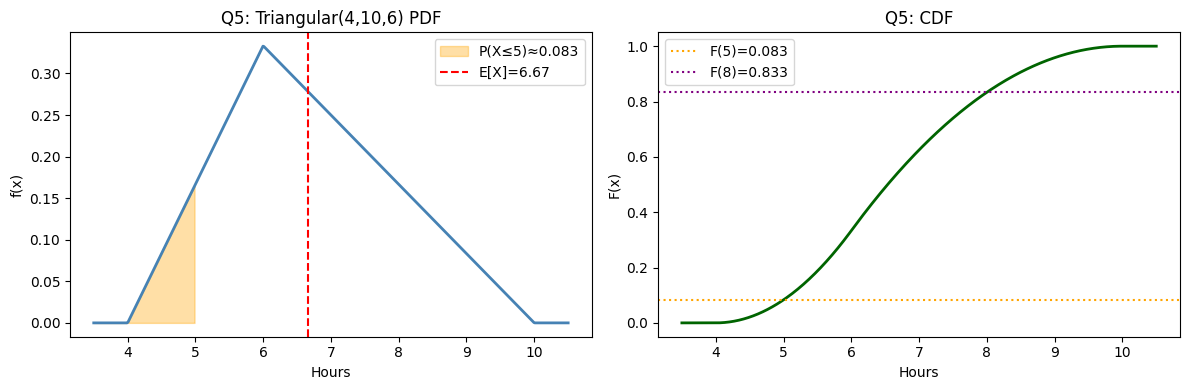

In [40]:
import numpy as np
from scipy.stats import triang
import matplotlib.pyplot as plt
from scipy.integrate import quad

a, b, c = 4.0, 10.0, 6.0   # min, max, mode

# 1. Support
print(f"1. Support of X: [{a}, {b}]  hours")

# 2. PDF of Triangular(a,b,c)
print(f"""
2. PDF of X ~ Triangular(a={a}, b={b}, c={c}):

   f(x) = 2(x-a) / [(b-a)(c-a)],   a ≤ x ≤ c
         = 2(b-x) / [(b-a)(b-c)],   c < x ≤ b
         = 0,                        otherwise
""")

def pdf(x):
    if a <= x <= c:
        return 2*(x-a)/((b-a)*(c-a))
    elif c < x <= b:
        return 2*(b-x)/((b-a)*(b-c))
    return 0.0

# 3. Verify ∫f = 1
integ, _ = quad(pdf, a, b)
print(f"3. ∫_a^b f(x)dx = {integ:.6f}  ✓")

# 4. Expectation  E[X] = (a + b + c)/3
print(f"""
4. E[X] = (a + b + c)/3 = ({a}+{b}+{c})/3 = {E_X:.4f} hours""")
E_X = (a + b + c) / 3

# 5. Variance  Var(X) = (a²+b²+c²-ab-ac-bc)/18
print(f"""
5. Var(X) = (a²+b²+c²-ab-ac-bc)/18 = {Var_X:.4f} hours²""")
Var_X = (a**2 + b**2 + c**2 - a*b - a*c - b*c) / 18
print(f"   Std(X) = {np.sqrt(Var_X):.4f} hours")

# 6. Interpretation of parameters
print(f"""
6. Parameter interpretation:
   a = {a}  hours – absolute minimum (best case)
   b = {b}  hours – absolute maximum (worst case)
   c = {c}  hours – most likely completion time (mode)
""")

# 7. Why Triangular is reasonable
print("""7. The Triangular distribution is reasonable when:
   - Only minimum, maximum, and mode estimates are available (common in PERT).
   - The distribution is simple to specify with expert judgment.
   - It is bounded, reflecting physical constraints on time.
   - It requires no historical data.
""")

# 8. P(X ≤ 5)
# CDF on lower branch: F(x) = (x-a)²/[(b-a)(c-a)] for a≤x≤c
x_val = 5.0
if x_val <= c:
    P_le5 = (x_val - a)**2 / ((b - a)*(c - a))
else:
    P_le5 = 1 - (b - x_val)**2 / ((b - a)*(b - c))
print(f"8. P(X ≤ 5) = (5-4)²/[(10-4)(6-4)] = 1/(6·2) = {P_le5:.4f}")

# 9. P(5 ≤ X ≤ 8)
x1, x2 = 5.0, 8.0
# CDF at x1 (on lower branch, since x1=5 ≤ c=6)
F_x1 = (x1 - a)**2 / ((b - a)*(c - a))
# CDF at x2 (on upper branch, since x2=8 > c=6)
F_x2 = 1 - (b - x2)**2 / ((b - a)*(b - c))
P_band = F_x2 - F_x1
print(f"""
9. P(5 ≤ X ≤ 8) = F(8) - F(5)""")
print(f"   F(5) = {F_x1:.4f}  (lower branch)")
print(f"   F(8) = {F_x2:.4f}  (upper branch: 1 - (10-8)²/[(10-4)(10-6)] = 1 - 4/24)")
print(f"   P(5 ≤ X ≤ 8) = {P_band:.4f}")

# 10. Project planning
print("""
10. Use in project planning / sensitivity analysis:
    - Schedule based on E[X] ≈ 6.67 hours; allocate buffer for Std ≈ 1.24 hours.
    - P(X ≤ 5) ≈ 8.3%: only ~8% chance of finishing in 5 hours or less.
    - P(5 ≤ X ≤ 8) ≈ 83%: most likely completion in 5–8 hours.
    - Sensitivity: vary a, b, c to explore impact on schedule uncertainty.
""")

# ── Plot ──────────────────────────────────────────────────────────────────
xs = np.linspace(a - 0.5, b + 0.5, 500)
# scipy triang: loc=a, scale=b-a, c=(mode-a)/(b-a)
c_norm = (c - a)/(b - a)
dist = triang(c_norm, loc=a, scale=b-a)
ys = dist.pdf(xs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, ys, 'steelblue', lw=2)
axes[0].fill_between(xs[xs<=5], dist.pdf(xs[xs<=5]), alpha=0.35, color='orange', label=f'P(X≤5)≈{P_le5:.3f}')
axes[0].axvline(E_X, color='red', linestyle='--', label=f'E[X]={E_X:.2f}')
axes[0].set_xlabel('Hours'); axes[0].set_ylabel('f(x)')
axes[0].set_title('Q5: Triangular(4,10,6) PDF'); axes[0].legend()

axes[1].plot(xs, dist.cdf(xs), 'darkgreen', lw=2)
axes[1].axhline(P_le5, color='orange', linestyle=':', label=f'F(5)={P_le5:.3f}')
axes[1].axhline(F_x2, color='purple', linestyle=':', label=f'F(8)={F_x2:.3f}')
axes[1].set_xlabel('Hours'); axes[1].set_ylabel('F(x)')
axes[1].set_title('Q5: CDF'); axes[1].legend()

plt.tight_layout()
plt.savefig('q5_triangular.png', dpi=100, bbox_inches='tight')
plt.show()

#Q6) Expected Project Completion Time Using PERT

A project manager is estimating the time required to complete a critical software integration task. Let $X$ denote the number of days required to complete the task. Based on expert judgment, the shortest possible time is $a=8$ days, the longest possible time is $b=20$ days, and the most likely completion time is $c=11$ days. Assume that $X$ follows a PERT distribution with parameters $(a,b,c)$.

The PERT distribution is defined as a Beta distribution scaled to the interval $[a,b]$, with internal shape parameters

$$
\alpha = 1 + 4\left( \frac{c-a}{b-a} \right)
$$

and

$$
\beta = 1 + 4\left( \frac{b-c}{b-a} \right).
$$

Its probability density function is

$$
f(x)=\frac{(x-a)^{\alpha-1}(b-x)^{\beta-1}}{B(\alpha,\beta)(b-a)^{\alpha+\beta-1}}, \qquad a \leq x \leq b,
$$

where

$$
B(\alpha,\beta)=\int_0^1 t^{\alpha-1}(1-t)^{\beta-1},dt.
$$

Answer the following:

1. Compute the values of the shape parameters $\alpha$ and $\beta$.

2. Specify the support of $X$.

3. Write down the probability density function $f_X(x)$ for this model.

4. State the probability space $(\Omega,\mathfrak F,P)$ suitable for this continuous model.

5. Define $X$ as a random variable on this space.

6. Compute the expectation $E[X]$ using the PERT formula

$$
E[X]=\frac{a+4c+b}{6}.
$$

7. Compute the variance $\mathrm{Var}(X)$ using the approximation

$$
\mathrm{Var}(X)=\frac{(E[X]-a)(b-E[X])}{7}.
$$

8. Compute the approximate standard deviation $\sigma$.

9. Briefly explain why a PERT distribution may be more appropriate than a Triangular distribution in this setting byt comparing the two results.

10. Interpret the practical meaning of the values $a$, $b$, $c$, $E[X]$, and $\sigma$ in the context of project planning.


1. Shape parameters:
   α = 1 + 4·(c-a)/(b-a) = 1 + 4·3/12 = 2.0000
   β = 1 + 4·(b-c)/(b-a) = 1 + 4·9/12 = 4.0000

2. Support of X: [8, 20]  days

3. PDF of X ~ PERT(a=8, b=20, c=11):

   f(x) = (x-8)^(α-1) · (20-x)^(β-1) / [B(α,β)·(20-8)^(α+β-1)],   8 ≤ x ≤ 20
   where α=2.0000, β=4.0000

4. Probability space (Ω, F, P):
   Ω = [8, 20], F = Borel σ-algebra on [8,20], P induced by PERT density above.

5. X: Ω → [8,20], X(ω) = ω  (duration in days)

6. E[X] = (a + 4c + b)/6 = (8 + 4·11 + 20)/6 = 12.0000 days

7. Var(X) = (E[X]-a)(b-E[X])/7 = (12.0000-8)·(20-12.0000)/7 = 4.5714 days²

8. σ = √Var(X) = 2.1381 days

9. PERT vs Triangular comparison (same a=8, b=20, c=11):
   PERT:       E[X] = 12.0000,  σ = 2.1381
   Triangular: E[X] = 13.0000,  σ = 2.5495

   PERT puts 4× weight on the mode c, so its mean is pulled closer to c
   and its variance is smaller.  This reflects expert judgment that the
   most likely time is more reliable than the extremes.  Triangular treats
   all three esti

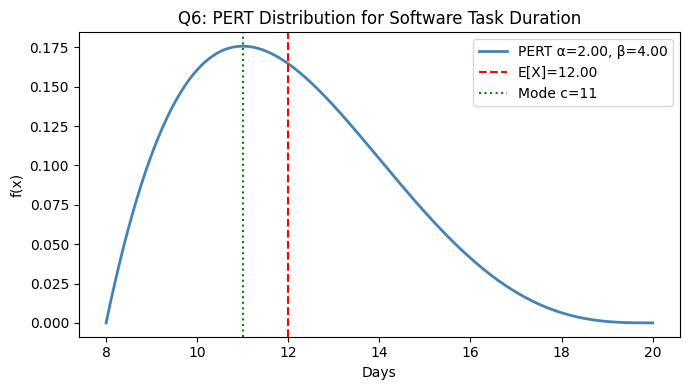

In [41]:
import numpy as np
from scipy.special import beta as beta_fn
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt

a, b, c = 8, 20, 11   # min, max, mode (days)

# 1. Shape parameters
alpha = 1 + 4*(c - a)/(b - a)
beta_p = 1 + 4*(b - c)/(b - a)
print(f"1. Shape parameters:")
print(f"   α = 1 + 4·(c-a)/(b-a) = 1 + 4·{c-a}/{b-a} = {alpha:.4f}")
print(f"   β = 1 + 4·(b-c)/(b-a) = 1 + 4·{b-c}/{b-a} = {beta_p:.4f}")

# 2. Support
print(f"""
2. Support of X: [{a}, {b}]  days""")

# 3. PDF
print(f"""
3. PDF of X ~ PERT(a={a}, b={b}, c={c}):

   f(x) = (x-{a})^(α-1) · ({b}-x)^(β-1) / [B(α,β)·({b}-{a})^(α+β-1)],   {a} ≤ x ≤ {b}
   where α={alpha:.4f}, β={beta_p:.4f}
""")

# 4. Probability space
print("4. Probability space (Ω, F, P):")
print(f"   Ω = [{a}, {b}], F = Borel σ-algebra on [{a},{b}], P induced by PERT density above.")

# 5. X as RV
print(f"""
5. X: Ω → [{a},{b}], X(ω) = ω  (duration in days)""")

# 6. Expectation
E_X = (a + 4*c + b) / 6
print(f"""
6. E[X] = (a + 4c + b)/6 = ({a} + 4·{c} + {b})/6 = {E_X:.4f} days""")

# 7. Variance
Var_X = (E_X - a)*(b - E_X) / 7
print(f"""
7. Var(X) = (E[X]-a)(b-E[X])/7 = ({E_X:.4f}-{a})·({b}-{E_X:.4f})/7 = {Var_X:.4f} days²""")

# 8. Standard deviation
sigma = np.sqrt(Var_X)
print(f"""
8. σ = √Var(X) = {sigma:.4f} days""")

# 9. PERT vs Triangular
a_T, b_T, c_T = 8, 20, 11
E_T = (a_T + b_T + c_T)/3
Var_T = (a_T**2 + b_T**2 + c_T**2 - a_T*b_T - a_T*c_T - b_T*c_T)/18
sigma_T = np.sqrt(Var_T)
print(f"""
9. PERT vs Triangular comparison (same a={a}, b={b}, c={c}):
   PERT:       E[X] = {E_X:.4f},  σ = {sigma:.4f}
   Triangular: E[X] = {E_T:.4f},  σ = {sigma_T:.4f}

   PERT puts 4× weight on the mode c, so its mean is pulled closer to c
   and its variance is smaller.  This reflects expert judgment that the
   most likely time is more reliable than the extremes.  Triangular treats
   all three estimates equally, giving a more spread-out distribution.
   PERT is generally preferred in project management (PMI/PMBOK).
""")

# 10. Interpretation
print(f"""10. Practical interpretation:
    a={a} days:   Optimistic (best-case) scenario.
    b={b} days:  Pessimistic (worst-case) scenario.
    c={c} days:  Most likely duration per expert judgment.
    E[X]={E_X:.2f} days: Expected (average) completion time.
    σ={sigma:.2f} days:  Typical deviation around the expected time;
                        plan for at least E[X]+2σ ≈ {E_X+2*sigma:.1f} days as buffer.
""")

# ── Plot ──────────────────────────────────────────────────────────────────
xs = np.linspace(a, b, 500)
# Rescale to standard Beta
c_norm = (xs - a) / (b - a)
pdf_vals = beta_dist.pdf(c_norm, alpha, beta_p) / (b - a)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, pdf_vals, 'steelblue', lw=2, label=f'PERT α={alpha:.2f}, β={beta_p:.2f}')
ax.axvline(E_X, color='red', linestyle='--', label=f'E[X]={E_X:.2f}')
ax.axvline(c, color='green', linestyle=':', label=f'Mode c={c}')
ax.set_xlabel('Days'); ax.set_ylabel('f(x)')
ax.set_title('Q6: PERT Distribution for Software Task Duration')
ax.legend(); plt.tight_layout()
plt.savefig('q6_pert.png', dpi=100, bbox_inches='tight')
plt.show()

#Q7) If the PERT Expectation is to Match Our Intuition

A project manager models the duration $X$ of a task by a PERT distribution with parameters $a$, $b$, and $c$, where $a$ is the minimum time, $b$ is the maximum time, and $c$ is the most likely time.

Suppose the minimum time is $a=5$ days and the most likely time is $c=11$ days. If the expected time computed from the PERT model is also to be the same as the most likely time:

1. Determine the value of the maximum time $b$.

2. What happens to the variance?

In [42]:
import sympy as sp

# Q7: PERT E[X] = mode  →  find b
# Given: a=5, c=11, E[X] = c = 11
a_val, c_val, E_target = 5, 11, 11   # E[X] must equal c = 11

# PERT formula: E[X] = (a + 4c + b)/6
# Set equal to 11 and solve for b:
b = sp.Symbol('b', positive=True)
E_expr = (a_val + 4*c_val + b) / 6
solution = sp.solve(sp.Eq(E_expr, E_target), b)
b_val = float(solution[0])

print("Q7 – PERT Expectation Matches Mode")
print("=" * 45)
print(f"Given: a={a_val}, c={c_val}, E[X] = c = {E_target}")
print(f"""
Solve (a + 4c + b)/6 = c  for b:""")
print(f"  ({a_val} + 4·{c_val} + b)/6 = {E_target}")
print(f"  {a_val + 4*c_val} + b = {6*E_target}")
print(f"  b = {6*E_target - a_val - 4*c_val}")
print(f"""
1. b = {b_val}""")

# 2. Variance when E[X] = c
Var_X = (E_target - a_val) * (b_val - E_target) / 7
print(f"""
2. Var(X) = (E[X]-a)(b-E[X])/7""")
print(f"          = ({E_target}-{a_val})·({b_val}-{E_target})/7")
print(f"          = {E_target - a_val}·{b_val - E_target}/7")
print(f"          = {Var_X:.4f} days²")
print(f"   σ = {Var_X**0.5:.4f} days")

print("""
Insight:
  For the PERT expectation to equal the mode c, the distribution must
  be symmetric around c within [a, b].  Here b - c = 17 - 11 = 6 and
  c - a = 11 - 5 = 6, confirming perfect symmetry.

  In this symmetric case the variance is (c-a)²/7 = 36/7 ≈ 5.14 days².
  A perfectly symmetric PERT with E[X]=mode has Var = (b-a)²/[4·(α+β+1)],
  which is lower than the Triangular counterpart, so the PERT distribution
  is more concentrated around the mode when E[X]=c.
""")

Q7 – PERT Expectation Matches Mode
Given: a=5, c=11, E[X] = c = 11

Solve (a + 4c + b)/6 = c  for b:
  (5 + 4·11 + b)/6 = 11
  49 + b = 66
  b = 17

1. b = 17.0

2. Var(X) = (E[X]-a)(b-E[X])/7
          = (11-5)·(17.0-11)/7
          = 6·6.0/7
          = 5.1429 days²
   σ = 2.2678 days

Insight:
  For the PERT expectation to equal the mode c, the distribution must
  be symmetric around c within [a, b].  Here b - c = 17 - 11 = 6 and
  c - a = 11 - 5 = 6, confirming perfect symmetry.

  In this symmetric case the variance is (c-a)²/7 = 36/7 ≈ 5.14 days².
  A perfectly symmetric PERT with E[X]=mode has Var = (b-a)²/[4·(α+β+1)],
  which is lower than the Triangular counterpart, so the PERT distribution
  is more concentrated around the mode when E[X]=c.



#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

In [43]:
# Q8: Probability of Both Girls Given At Least One Girl

# Sample space: ordered pairs (first child, second child)
sample_space = [('B','B'), ('B','G'), ('G','B'), ('G','G')]
print("Sample space Ω = {BB, BG, GB, GG}, each with probability 1/4")

# Event A: both girls
A = {('G','G')}
# Event B: at least one girl
B = {('B','G'), ('G','B'), ('G','G')}

P_A = len(A) / len(sample_space)
P_B = len(B) / len(sample_space)
A_and_B = A & B
P_A_and_B = len(A_and_B) / len(sample_space)

# Conditional probability P(A | B) = P(A ∩ B) / P(B)
P_A_given_B = P_A_and_B / P_B

print(f"""
P(both girls) = P(GG) = {P_A}""")
print(f"P(at least one girl) = P(BG ∪ GB ∪ GG) = {P_B}")
print(f"P(both girls AND at least one girl) = {P_A_and_B}")
print(f"""
P(both girls | at least one girl)""")
print(f"  = P(GG ∩ {{BG,GB,GG}}) / P({{BG,GB,GG}})")
print(f"  = {P_A_and_B} / {P_B}")
print(f"  = {P_A_given_B:.4f}  =  1/3")

print("""
Interpretation:
  Given that at least one child is a girl, the three equally likely outcomes
  consistent with this condition are {BG, GB, GG}.  Only one of these has
  both children as girls, so P(GG | ≥1 girl) = 1/3.

  This is different from P(second is G | first is G) = 1/2  — a common
  source of confusion.  The key is that the conditioning event "at least one
  girl" does not tell us *which* child is the girl.
""")

Sample space Ω = {BB, BG, GB, GG}, each with probability 1/4

P(both girls) = P(GG) = 0.25
P(at least one girl) = P(BG ∪ GB ∪ GG) = 0.75
P(both girls AND at least one girl) = 0.25

P(both girls | at least one girl)
  = P(GG ∩ {BG,GB,GG}) / P({BG,GB,GG})
  = 0.25 / 0.75
  = 0.3333  =  1/3

Interpretation:
  Given that at least one child is a girl, the three equally likely outcomes
  consistent with this condition are {BG, GB, GG}.  Only one of these has
  both children as girls, so P(GG | ≥1 girl) = 1/3.

  This is different from P(second is G | first is G) = 1/2  — a common
  source of confusion.  The key is that the conditioning event "at least one
  girl" does not tell us *which* child is the girl.



# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

1. Probability space (Ω, F, P):
   Ω = {G1, G2, D1, D2}
   F = P(Ω) = power set (16 subsets)
   P({G1}) = 0.5
   P({G2}) = 0.2
   P({D1}) = 0.1
   P({D2}) = 0.2

2. σ(X):
   X takes value 0 on {G1,G2} and 1 on {D1,D2}.
   σ(X) = {∅, {G1,G2}, {D1,D2}, Ω}

3. σ(Y):
   Y is injective → σ(Y) = P(Ω) (all 16 subsets)

4. σ(X) ⊆ σ(Y): Every set in σ(X) is a union of singletons, hence in P(Ω)=σ(Y). ✓
   Y carries more information because it distinguishes *which* machine produced the item.

5. Marginal distribution of X:
   P(X=0) = P(G1)+P(G2) = 0.5+0.2 = 0.7
   P(X=1) = P(D1)+P(D2) = 0.1+0.2 = 0.30000000000000004

6. Marginal distribution of Y (each singleton):
   P(Y=1) = P({G1}) = 0.5
   P(Y=2) = P({G2}) = 0.2
   P(Y=3) = P({D1}) = 0.1
   P(Y=4) = P({D2}) = 0.2

7. Joint probabilities P(X=x, Y=y):
   P(X=0,Y=1) = P(G1) = 0.5  (G1 is good on machine 1)
   P(X=0,Y=2) = P(G2) = 0.2
   P(X=1,Y=3) = P(D1) = 0.1
   P(X=1,Y=4) = P(D2) = 0.2
   (All other joint probs = 0, since X is determined by Y

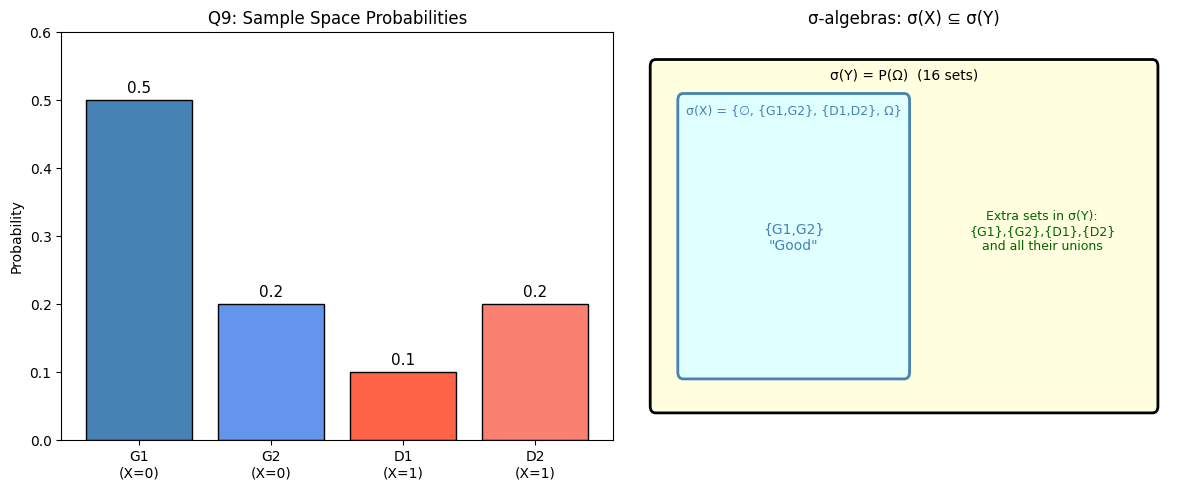

12. Shannon Entropy:
   H(X) = 0.8813 bits
   H(Y) = 1.7610 bits
   H(X,Y) = H(Y) = 1.7610 bits  (X is a function of Y)
   H(X|Y) = H(X,Y) - H(Y) = 0.0000 bits  (Y fully determines X)
   H(Y|X) = H(X,Y) - H(X) = 0.8797 bits
   Mutual info I(X;Y) = H(X) - H(X|Y) = 0.8813 bits
   (Y carries 0.8813 bits about X, but X carries only 0.8813 bits about Y)


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import entropy

# ── Setup ─────────────────────────────────────────────────────────────────────
omega = ['G1', 'G2', 'D1', 'D2']
P     = {'G1': 0.50, 'G2': 0.20, 'D1': 0.10, 'D2': 0.20}

# X: quality indicator  (0=good, 1=defective)
X_map = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1}
# Y: full label (1..4)
Y_map = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4}

# 1. Probability space
print("1. Probability space (Ω, F, P):")
print("   Ω = {G1, G2, D1, D2}")
print("   F = P(Ω) = power set (16 subsets)")
for w in omega:
    print(f"   P({{{w}}}) = {P[w]}")

# 2. σ(X)
print("""
2. σ(X):""")
print("   X takes value 0 on {G1,G2} and 1 on {D1,D2}.")
print("   σ(X) = {∅, {G1,G2}, {D1,D2}, Ω}")

# 3. σ(Y)
print("""
3. σ(Y):""")
print("   Y is injective → σ(Y) = P(Ω) (all 16 subsets)")

# 4. σ(X) ⊆ σ(Y)
print("""
4. σ(X) ⊆ σ(Y): Every set in σ(X) is a union of singletons, hence in P(Ω)=σ(Y). ✓""")
print("   Y carries more information because it distinguishes *which* machine produced the item.")

# 5. Marginal of X
p_X0 = sum(P[w] for w in omega if X_map[w] == 0)
p_X1 = sum(P[w] for w in omega if X_map[w] == 1)
print(f"""
5. Marginal distribution of X:""")
print(f"   P(X=0) = P(G1)+P(G2) = {P['G1']}+{P['G2']} = {p_X0}")
print(f"   P(X=1) = P(D1)+P(D2) = {P['D1']}+{P['D2']} = {p_X1}")

# 6. Marginal of Y
print("""
6. Marginal distribution of Y (each singleton):""")
for w in omega:
    print(f"   P(Y={Y_map[w]}) = P({{{w}}}) = {P[w]}")

# 7. Joint probabilities
print("""
7. Joint probabilities P(X=x, Y=y):""")
print(f"   P(X=0,Y=1) = P(G1) = {P['G1']}  (G1 is good on machine 1)")
print(f"   P(X=0,Y=2) = P(G2) = {P['G2']}")
print(f"   P(X=1,Y=3) = P(D1) = {P['D1']}")
print(f"   P(X=1,Y=4) = P(D2) = {P['D2']}")
print("   (All other joint probs = 0, since X is determined by Y)")

# 8. Conditional probabilities
print("""
8. Conditional probabilities:""")
# P(X=1 | Y=3): Y=3 means D1, which has X=1 → P=1
print(f"   P(X=1|Y=3) = P(X=1,Y=3)/P(Y=3) = {P['D1']}/{P['D1']} = 1.0")
print(f"   P(X=1|Y=4) = P(X=1,Y=4)/P(Y=4) = {P['D2']}/{P['D2']} = 1.0")
# P(Y=3 | X=1)
p_Y3_given_X1 = P['D1'] / p_X1
p_Y4_given_X1 = P['D2'] / p_X1
print(f"   P(Y=3|X=1) = P(D1)/P(X=1) = {P['D1']}/{p_X1} = {p_Y3_given_X1:.4f}")
print(f"   P(Y=4|X=1) = P(D2)/P(X=1) = {P['D2']}/{p_X1} = {p_Y4_given_X1:.4f}")

# 9. Interpretation
print("""
9. Interpretation:
   - Conditioning on Y tells us *exactly* which machine produced the item,
     so X is completely determined (hence P(X|Y)=0 or 1).
   - Conditioning on X (e.g. X=1) only tells us "defective"; Y=3 or Y=4
     are still uncertain, with probabilities reflecting the relative
     frequency of defects from each machine.
""")

# 10.
print("""10. Information in σ(X) vs σ(Y):
    σ(X) contains only quality information (good/defective) — not machine.
    σ(Y) = P(Ω) contains all information, including which machine.
    σ(X) ⊂ σ(Y) strictly: σ(Y) adds knowledge of the producing machine,
    which σ(X) completely discards.
""")

# 11. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Probability bar chart
ax = axes[0]
bar_labels = ['G1\n(X=0)', 'G2\n(X=0)', 'D1\n(X=1)', 'D2\n(X=1)']
bar_probs  = [P[w] for w in omega]
colors     = ['steelblue', 'cornflowerblue', 'tomato', 'salmon']
bars = ax.bar(bar_labels, bar_probs, color=colors, edgecolor='black')
ax.set_ylabel('Probability'); ax.set_title('Q9: Sample Space Probabilities')
ax.set_ylim(0, 0.6)
for bar, val in zip(bars, bar_probs):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val}', ha='center', fontsize=11)

# σ-algebra diagram (Venn-style)
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 6); ax2.axis('off')
ax2.set_title('σ-algebras: σ(X) ⊆ σ(Y)')
ax2.add_patch(mpatches.FancyBboxPatch((0.5, 0.5), 9, 5, boxstyle='round,pad=0.1',
              edgecolor='black', facecolor='lightyellow', lw=2))
ax2.add_patch(mpatches.FancyBboxPatch((1, 1), 4, 4, boxstyle='round,pad=0.1',
              edgecolor='steelblue', facecolor='lightcyan', lw=2))
ax2.text(5, 5.3, 'σ(Y) = P(Ω)  (16 sets)', ha='center', color='black', fontsize=10)
ax2.text(3, 4.8, 'σ(X) = {∅, {G1,G2}, {D1,D2}, Ω}', ha='center', color='steelblue', fontsize=9)
ax2.text(3, 2.8, '{G1,G2}\n"Good"', ha='center', color='steelblue', fontsize=10)
ax2.text(7.5, 2.8, 'Extra sets in σ(Y):\n{G1},{G2},{D1},{D2}\nand all their unions',
         ha='center', color='darkgreen', fontsize=9)

plt.tight_layout()
plt.savefig('q9_viz.png', dpi=100, bbox_inches='tight')
plt.show()

# 12. Shannon Entropy
print("12. Shannon Entropy:")
# Marginal H(X)
H_X = entropy([p_X0, p_X1], base=2)
# Marginal H(Y)
py_vals = [P[w] for w in omega]
H_Y = entropy(py_vals, base=2)
# Joint H(X,Y) = H(Y) since (X,Y) uniquely determined by Y
H_XY = H_Y
# Conditional H(X|Y) = H(X,Y) - H(Y) = 0 (X is function of Y)
H_X_given_Y = H_XY - H_Y
# Conditional H(Y|X)
H_Y_given_X = H_XY - H_X

print(f"   H(X) = {H_X:.4f} bits")
print(f"   H(Y) = {H_Y:.4f} bits")
print(f"   H(X,Y) = H(Y) = {H_XY:.4f} bits  (X is a function of Y)")
print(f"   H(X|Y) = H(X,Y) - H(Y) = {H_X_given_Y:.4f} bits  (Y fully determines X)")
print(f"   H(Y|X) = H(X,Y) - H(X) = {H_Y_given_X:.4f} bits")
print(f"   Mutual info I(X;Y) = H(X) - H(X|Y) = {H_X - H_X_given_Y:.4f} bits")
print(f"   (Y carries {H_X:.4f} bits about X, but X carries only {H_Y - H_Y_given_X:.4f} bits about Y)")


# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


1. Probability Space:
   Ω = ℝ²
   F = B(ℝ²)  (Borel σ-algebra on ℝ²)
   P induced by  f_{T,P}(t,p) = (1/4π) exp(-t²/2 - p²/8)

2. σ(X) where X(t,p)=t:
   σ(X) = {X⁻¹(B) : B ∈ B(ℝ)} = {B × ℝ : B ∈ B(ℝ)}
   (horizontal strips — only temperature information)

3. σ(Y) where Y(t,p)=(t,p):
   σ(Y) = B(ℝ²)  (all Borel sets in the plane)

4. σ(X) ⊆ σ(Y):
   Every set B×ℝ is a Borel set in ℝ², hence in σ(Y)=B(ℝ²). ✓
   Y records (T,P) jointly, so it carries pressure info that X discards.

5. Marginal density of X = T:
   f_X(t) = (1/√(2π)) exp(-t²/2)   [standard normal]

6. Marginal density of Y = (T,P):
   f_Y(t,p) = (1/4π) exp(-t²/2 - p²/8)
   (product of N(0,1) and N(0,4) by independence)

7. Probabilities:
   P(X ≤ 0)               = 0.5000
   P(X > 1)               = 0.1587
   P(Y ∈ (-∞,0]×ℝ)       = P(T≤0) = 0.5000
   P(Y ∈ [-1,1]×[-2,2])  = P(-1≤T≤1)·P(-2≤P≤2) = 0.6827·0.6827 = 0.4661

8. Conditional distribution of X given Y=(t,p):
   Since X(t,p)=t, knowing Y=(t,p) completely determin

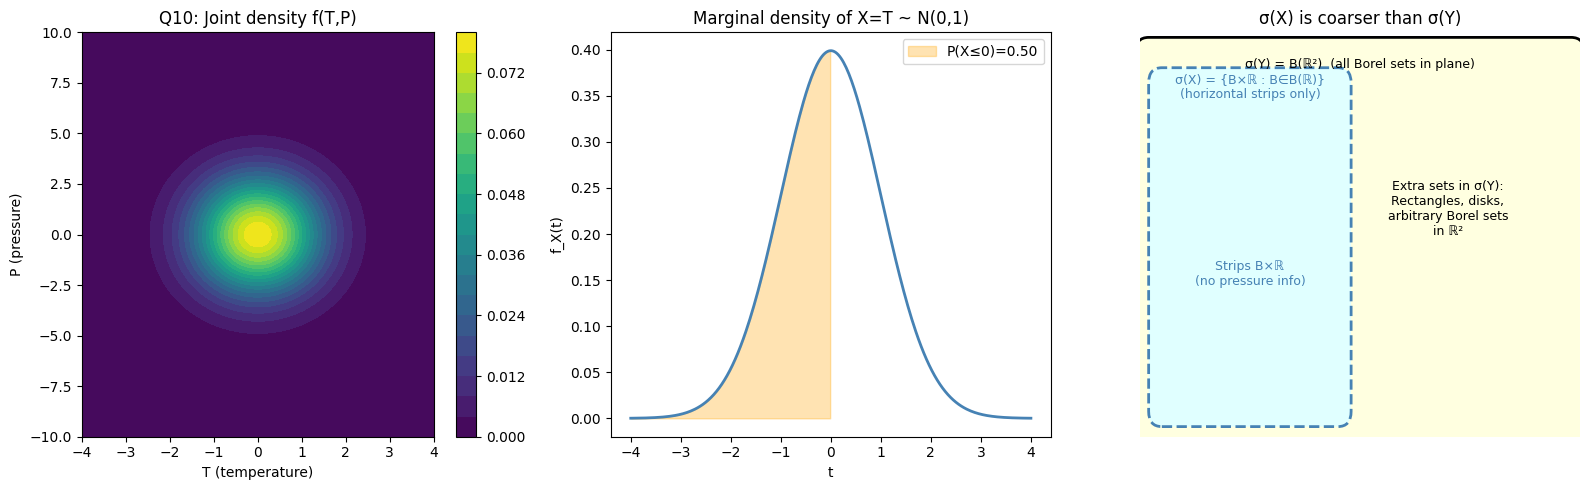


13. h(X) = (1/2)ln(2πe·1) = 1.4189 nats

14. h(Y) = h(T) + h(P) = 1.4189 + 2.1121 = 3.5310 nats

15. h(Y|X) = h(P|T) = h(P) = 2.1121 nats
    Interpretation: After observing T, we still have full uncertainty
    about P (by independence).  The remaining entropy is entirely from P.

16. h(X|Y):
    Since X = π₁(Y), knowing Y=(t,p) completely determines X=t.
    So X|Y is degenerate, but in the continuous case a degenerate
    distribution has no density → h(X|Y) = -∞ in the differential sense.

    This differs from the discrete case: in discrete probability,
    if X is a function of Y then H(X|Y)=0.  In the continuous case,
    conditioning on a continuous Y collapses the conditional
    distribution to a point mass, and the differential entropy of a
    point mass is -∞ (not 0).  This reflects the fundamental difference
    between Shannon entropy (discrete) and differential entropy (continuous).



In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import dblquad, quad

# Q10: Continuous Random Variables – Temperature (T) and Pressure (P) deviations
# T ~ N(0,1),  P ~ N(0,4),  independent

# 1. Probability space
print("1. Probability Space:")
print("   Ω = ℝ²")
print("   F = B(ℝ²)  (Borel σ-algebra on ℝ²)")
print("   P induced by  f_{T,P}(t,p) = (1/4π) exp(-t²/2 - p²/8)")

# 2. σ(X)
print("""
2. σ(X) where X(t,p)=t:""")
print("   σ(X) = {X⁻¹(B) : B ∈ B(ℝ)} = {B × ℝ : B ∈ B(ℝ)}")
print("   (horizontal strips — only temperature information)")

# 3. σ(Y)
print("""
3. σ(Y) where Y(t,p)=(t,p):""")
print("   σ(Y) = B(ℝ²)  (all Borel sets in the plane)")

# 4. σ(X) ⊆ σ(Y)
print("""
4. σ(X) ⊆ σ(Y):""")
print("   Every set B×ℝ is a Borel set in ℝ², hence in σ(Y)=B(ℝ²). ✓")
print("   Y records (T,P) jointly, so it carries pressure info that X discards.")

# 5. Marginal density of X = T ~ N(0,1)
print("""
5. Marginal density of X = T:""")
print("   f_X(t) = (1/√(2π)) exp(-t²/2)   [standard normal]")

# 6. Marginal density of Y = (T,P)
print("""
6. Marginal density of Y = (T,P):""")
print("   f_Y(t,p) = (1/4π) exp(-t²/2 - p²/8)")
print("   (product of N(0,1) and N(0,4) by independence)")

# 7. Probabilities
P_X_le0 = norm.cdf(0, 0, 1)
P_X_gt1 = 1 - norm.cdf(1, 0, 1)
# P(Y ∈ (-∞,0] × ℝ) = P(T≤0) by independence and marginalising P
P_Y_strip = norm.cdf(0, 0, 1)
# P(Y ∈ [-1,1]×[-2,2]) = P(-1≤T≤1)·P(-2≤P≤2)
P_T_band = norm.cdf(1,0,1) - norm.cdf(-1,0,1)
P_P_band = norm.cdf(2,0,2) - norm.cdf(-2,0,2)   # P~N(0,4) => std=2
P_Y_rect = P_T_band * P_P_band

print(f"""
7. Probabilities:""")
print(f"   P(X ≤ 0)               = {P_X_le0:.4f}")
print(f"   P(X > 1)               = {P_X_gt1:.4f}")
print(f"   P(Y ∈ (-∞,0]×ℝ)       = P(T≤0) = {P_Y_strip:.4f}")
print(f"   P(Y ∈ [-1,1]×[-2,2])  = P(-1≤T≤1)·P(-2≤P≤2) = {P_T_band:.4f}·{P_P_band:.4f} = {P_Y_rect:.4f}")

# 8. Conditional X | Y=(t,p)
print("""
8. Conditional distribution of X given Y=(t,p):""")
print("   Since X(t,p)=t, knowing Y=(t,p) completely determines X=t.")
print("   So X|Y=(t,p) is the degenerate distribution concentrated at t.")

# 9. Conditional Y | X=t
print("""
9. Conditional distribution of Y given X=t:""")
print("   f_{Y|X=t}(t,p) = f_{T,P}(t,p)/f_T(t) = f_P(p) = (1/4√π)exp(-p²/8)")
print("   i.e. P|T=t is still N(0,4) — independence means T tells nothing about P.")

# 10.
print("""
10. Conditioning on X vs Y:
    Conditioning on X=t reveals only the temperature deviation.
    Conditioning on Y=(t,p) reveals both temperature AND pressure,
    fully pinning the state of the system.
    The extra information in Y (over X) is exactly the pressure P.
""")

# 11. X = π₁ ∘ Y
print("""11. X = π₁ ∘ Y:
    π₁(t,p) = t (projection), so X(ω) = π₁(Y(ω)) for all ω.
    Since π₁ is Borel-measurable, X is a measurable function of Y.
    This implies σ(X) ⊆ σ(Y).
""")

# 12. Visualisation
t_grid = np.linspace(-4, 4, 300)
p_grid = np.linspace(-10, 10, 300)
T_g, P_g = np.meshgrid(t_grid, p_grid)
Z = (1/(4*np.pi)) * np.exp(-T_g**2/2 - P_g**2/8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Joint density contour
cp = axes[0].contourf(T_g, P_g, Z, levels=20, cmap='viridis')
fig.colorbar(cp, ax=axes[0])
axes[0].set_xlabel('T (temperature)'); axes[0].set_ylabel('P (pressure)')
axes[0].set_title('Q10: Joint density f(T,P)')

# Marginal of X=T
axes[1].plot(t_grid, norm.pdf(t_grid, 0, 1), 'steelblue', lw=2)
axes[1].set_xlabel('t'); axes[1].set_ylabel('f_X(t)')
axes[1].set_title('Marginal density of X=T ~ N(0,1)')
axes[1].fill_between(t_grid[t_grid<=0], norm.pdf(t_grid[t_grid<=0], 0, 1),
                     alpha=0.3, color='orange', label=f'P(X≤0)={P_X_le0:.2f}')
axes[1].legend()

# σ-algebra coarseness diagram
ax3 = axes[2]
ax3.set_xlim(0,10); ax3.set_ylim(0,8); ax3.axis('off')
ax3.set_title('σ(X) is coarser than σ(Y)')
import matplotlib.patches as mpatches
ax3.add_patch(mpatches.FancyBboxPatch((0.2,0.2),9.6,7.4, boxstyle='round',
              edgecolor='black', facecolor='lightyellow', lw=2))
ax3.add_patch(mpatches.FancyBboxPatch((0.5,0.5),4,6.5, boxstyle='round',
              edgecolor='steelblue', facecolor='lightcyan', lw=2, linestyle='--'))
ax3.text(5,7.3,'σ(Y) = B(ℝ²)  (all Borel sets in plane)', ha='center', fontsize=9)
ax3.text(2.5,6.7,'''σ(X) = {B×ℝ : B∈B(ℝ)}
(horizontal strips only)''',
         ha='center', color='steelblue', fontsize=9)
ax3.text(7,4,'''Extra sets in σ(Y):
Rectangles, disks,
arbitrary Borel sets
in ℝ²''', ha='center', fontsize=9)
ax3.text(2.5,3,'''Strips B×ℝ
(no pressure info)''', ha='center', color='steelblue', fontsize=9)

plt.tight_layout()
plt.savefig('q10_viz.png', dpi=100, bbox_inches='tight')
plt.show()

# 13. Differential entropy of X ~ N(0,1)
# h(N(0,σ²)) = (1/2)ln(2πeσ²)
h_X = 0.5 * np.log(2*np.pi*np.e*1)
print(f"""
13. h(X) = (1/2)ln(2πe·1) = {h_X:.4f} nats""")

# 14. Differential entropy of Y = (T,P) with T~N(0,1), P~N(0,4), independent
# h(Y) = h(T) + h(P) by independence
h_T = 0.5 * np.log(2*np.pi*np.e*1)
h_P = 0.5 * np.log(2*np.pi*np.e*4)
h_Y = h_T + h_P
print(f"""
14. h(Y) = h(T) + h(P) = {h_T:.4f} + {h_P:.4f} = {h_Y:.4f} nats""")

# 15. h(Y|X) = h(Y) - h(X) [since X=T, and T,P independent]
# Knowing X=T, P remains N(0,4) → h(Y|X) = h(P) = h(P)
h_Y_given_X = h_P
print(f"""
15. h(Y|X) = h(P|T) = h(P) = {h_Y_given_X:.4f} nats""")
print("    Interpretation: After observing T, we still have full uncertainty")
print("    about P (by independence).  The remaining entropy is entirely from P.")

# 16. h(X|Y)
print("""
16. h(X|Y):
    Since X = π₁(Y), knowing Y=(t,p) completely determines X=t.
    So X|Y is degenerate, but in the continuous case a degenerate
    distribution has no density → h(X|Y) = -∞ in the differential sense.

    This differs from the discrete case: in discrete probability,
    if X is a function of Y then H(X|Y)=0.  In the continuous case,
    conditioning on a continuous Y collapses the conditional
    distribution to a point mass, and the differential entropy of a
    point mass is -∞ (not 0).  This reflects the fundamental difference
    between Shannon entropy (discrete) and differential entropy (continuous).
""")


#Q11) Conditional Expectation

A bank monitors credit-card transactions for possible fraud.

For each transaction, let the sample space be

$$
\Omega=\{\omega_1,\omega_2,\omega_3,\omega_4\},
$$

where:

* $\omega_1$: low-risk customer, legitimate transaction,
* $\omega_2$: low-risk customer, fraudulent transaction,
* $\omega_3$: high-risk customer, legitimate transaction,
* $\omega_4$: high-risk customer, fraudulent transaction.

Assume the probabilities are

$$
P(\{\omega_1\})=0.50,\qquad
P(\{\omega_2\})=0.10,\qquad
P(\{\omega_3\})=0.20,\qquad
P(\{\omega_4\})=0.20.
$$

Let $X:\Omega\to\mathbb R$ denote the fraud indicator:

$$
X(\omega_1)=0,\qquad
X(\omega_2)=1,\qquad
X(\omega_3)=0,\qquad
X(\omega_4)=1.
$$

Thus $X=1$ means the transaction is fraudulent, and $X=0$ means it is legitimate.

Now suppose the bank does not observe the full outcome $\omega$, but only the customer’s risk class. Define $Y:\Omega\to\mathbb R$ by

$$
Y(\omega_1)=0,\qquad
Y(\omega_2)=0,\qquad
Y(\omega_3)=1,\qquad
Y(\omega_4)=1.
$$

Thus:

* $Y=0$ means “low-risk customer,”
* $Y=1$ means “high-risk customer.”

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

3. Explain why $E[X\mid Y]$ must be $\sigma(Y)$-measurable, and therefore must be constant on the sets ${ \omega_1,\omega_2}$ and ${\omega_3,\omega_4}$.

4. Compute $E[X\mid Y]$ explicitly.

5. Verify the defining property of conditional expectation by checking that for every set $A\in\sigma(Y)$,

$$
\int_A E[X\mid Y]\,dP=\int_A X\,dP.
$$

6. Compute $E[X]$ and compare it with $E[X\mid Y]$.

7. Interpret $E[X\mid Y]$ in practical terms. What does it tell the bank?

8. Let

$$
\mathfrak G=\mathfrak P(\Omega).
$$

Compute $E[X\mid \mathfrak G]$ and compare it with $E[X\mid Y]$.

9. Explain how this example shows that conditional expectation is the “best estimate of $X$ using only the information contained in $Y$.”

In [46]:
import numpy as np

# Q11: Conditional Expectation – Fraud Detection
omega = ['w1','w2','w3','w4']
label = {'w1':'Low-risk, Legit','w2':'Low-risk, Fraud',
         'w3':'High-risk, Legit','w4':'High-risk, Fraud'}
P = {'w1':0.50,'w2':0.10,'w3':0.20,'w4':0.20}

# Fraud indicator X
X = {'w1':0,'w2':1,'w3':0,'w4':1}
# Risk class Y  (0=low, 1=high)
Y = {'w1':0,'w2':0,'w3':1,'w4':1}

# 1. Probability space
print("1. Probability space (Ω, F, P):")
print("   Ω = {ω₁,ω₂,ω₃,ω₄}")
print("   F = P(Ω)  (all 16 subsets)")
for w in omega:
    print(f"   P({{{w}}}) = {P[w]}  [{label[w]}]")

# 2. σ(Y)
print("""
2. σ(Y):""")
print("   Y takes value 0 on {ω₁,ω₂} and 1 on {ω₃,ω₄}.")
print("   σ(Y) = {∅, {ω₁,ω₂}, {ω₃,ω₄}, Ω}")

# 3. Why E[X|Y] must be σ(Y)-measurable
print("""
3. E[X|Y] is σ(Y)-measurable by definition of conditional expectation.""")
print("   It must be constant on each atom of σ(Y): {ω₁,ω₂} and {ω₃,ω₄}.")

# 4. Compute E[X|Y]
# On {ω₁,ω₂}: E[X|Y=0] = (X(ω₁)P(ω₁) + X(ω₂)P(ω₂)) / P(Y=0)
P_Y0 = P['w1'] + P['w2']
P_Y1 = P['w3'] + P['w4']
E_X_Y0 = (X['w1']*P['w1'] + X['w2']*P['w2']) / P_Y0
E_X_Y1 = (X['w3']*P['w3'] + X['w4']*P['w4']) / P_Y1

print(f"""
4. E[X|Y]:""")
print(f"   E[X|Y=0] = (0·0.50 + 1·0.10)/(0.50+0.10) = {E_X_Y0:.4f}")
print(f"   E[X|Y=1] = (0·0.20 + 1·0.20)/(0.20+0.20) = {E_X_Y1:.4f}")
print(f"   So E[X|Y](ω) = {E_X_Y0:.4f} for ω∈{{ω₁,ω₂}}, {E_X_Y1:.4f} for ω∈{{ω₃,ω₄}}")

# 5. Verify defining property: ∫_A E[X|Y] dP = ∫_A X dP for each A∈σ(Y)
print("""
5. Verification of defining property ∫_A E[X|Y] dP = ∫_A X dP:""")
sigma_Y_sets = [
    ('∅', []),
    ('{ω₁,ω₂}', ['w1','w2']),
    ('{ω₃,ω₄}', ['w3','w4']),
    ('Ω', omega)
]
cond_exp_val = {'w1': E_X_Y0, 'w2': E_X_Y0, 'w3': E_X_Y1, 'w4': E_X_Y1}
for name, members in sigma_Y_sets:
    lhs = sum(cond_exp_val[w]*P[w] for w in members)
    rhs = sum(X[w]*P[w] for w in members)
    check = "✓" if abs(lhs-rhs)<1e-10 else "✗"
    print(f"   A={name}: LHS={lhs:.4f}, RHS={rhs:.4f}  {check}")

# 6. E[X]
E_X = sum(X[w]*P[w] for w in omega)
print(f"""
6. E[X] = {E_X:.4f}""")
print(f"   E[E[X|Y]] = {E_X_Y0}·{P_Y0} + {E_X_Y1}·{P_Y1} = {E_X_Y0*P_Y0 + E_X_Y1*P_Y1:.4f}  (Tower property ✓)")

# 7. Practical interpretation
print(f"""
7. Interpretation:
   E[X|Y=0] ≈ {E_X_Y0:.4f}:  A low-risk customer has a ~{E_X_Y0*100:.1f}% chance of fraud.
   E[X|Y=1] = {E_X_Y1:.4f}:  A high-risk customer has a {E_X_Y1*100:.0f}% chance of fraud.
   E[X|Y] gives the bank a customer-class-specific fraud probability,
   allowing differentiated risk management (e.g. extra checks for high-risk).
""")

# 8. E[X | G] where G = P(Ω)
print("8. E[X | G] where G = P(Ω) (full information):")
print("   With full information, the conditional expectation simply equals X itself.")
print("   E[X|G](ω) = X(ω) for each ω:")
for w in omega:
    print(f"   E[X|G]({w}) = X({w}) = {X[w]}")
print(f"""
   This is finer than E[X|Y], which only has two values {{{E_X_Y0:.4f}, {E_X_Y1:.4f}}}.""")

# 9. Best estimate interpretation
print("""
9. Conditional expectation as best estimate:
   E[X|Y] is the MMSE (minimum mean-squared-error) estimator of X
   using only the information in Y (risk class).

   - If the bank knows only Y (risk class), E[X|Y] is its best guess for X.
   - Using E[X|G]=X would require knowing the true fraud status—defeating the purpose.
   - E[X|Y] balances available information with prediction quality:
     it averages out within each risk class, giving a probability estimate
     that is optimal under squared-error loss given only Y.
""")


1. Probability space (Ω, F, P):
   Ω = {ω₁,ω₂,ω₃,ω₄}
   F = P(Ω)  (all 16 subsets)
   P({w1}) = 0.5  [Low-risk, Legit]
   P({w2}) = 0.1  [Low-risk, Fraud]
   P({w3}) = 0.2  [High-risk, Legit]
   P({w4}) = 0.2  [High-risk, Fraud]

2. σ(Y):
   Y takes value 0 on {ω₁,ω₂} and 1 on {ω₃,ω₄}.
   σ(Y) = {∅, {ω₁,ω₂}, {ω₃,ω₄}, Ω}

3. E[X|Y] is σ(Y)-measurable by definition of conditional expectation.
   It must be constant on each atom of σ(Y): {ω₁,ω₂} and {ω₃,ω₄}.

4. E[X|Y]:
   E[X|Y=0] = (0·0.50 + 1·0.10)/(0.50+0.10) = 0.1667
   E[X|Y=1] = (0·0.20 + 1·0.20)/(0.20+0.20) = 0.5000
   So E[X|Y](ω) = 0.1667 for ω∈{ω₁,ω₂}, 0.5000 for ω∈{ω₃,ω₄}

5. Verification of defining property ∫_A E[X|Y] dP = ∫_A X dP:
   A=∅: LHS=0.0000, RHS=0.0000  ✓
   A={ω₁,ω₂}: LHS=0.1000, RHS=0.1000  ✓
   A={ω₃,ω₄}: LHS=0.2000, RHS=0.2000  ✓
   A=Ω: LHS=0.3000, RHS=0.3000  ✓

6. E[X] = 0.3000
   E[E[X|Y]] = 0.16666666666666669·0.6 + 0.5·0.4 = 0.3000  (Tower property ✓)

7. Interpretation:
   E[X|Y=0] ≈ 0.1667:  A low-risk